In [1]:
import sys
sys.path.append("../")

import numpy as np
np.random.seed(42)

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.ar_model import AutoReg
from data_loader import PairData

data = PairData("../../data/real_pair_MCD_YUM.csv")
n  = len(data)
q1 = n // 4
q4 = 3 * n // 4

jres      = coint_johansen(np.log(data.s[:, :q1]).T, det_order=0, k_ar_diff=1)
cv        = jres.evec[:, 0]
beta      = -cv[1] / cv[0]
intercept = float((np.log(data.s[0, :q1]) - beta * np.log(data.s[1, :q1])).mean())
spread_q1 = np.log(data.s[0, :q1]) - beta * np.log(data.s[1, :q1]) - intercept
fixed_std = float(spread_q1.std())
phi       = AutoReg(spread_q1, lags=1).fit().params[1]
wn_var    = fixed_std ** 2 * (1 - phi ** 2)

print(f"\u03b2={beta:.4f}  intercept={intercept:.4f}  std={fixed_std:.4f}  \u03c6={phi:.4f}")
print(f"Training data (Q1-Q3): 0\u2013{q4}  ({q4} steps)")
print(f"Real test (Q4): {q4}\u2013{n}  ({n - q4} steps)")

N, T = 50, q4
log_s1 = np.cumsum(np.c_[np.full(N, np.log(100.0)),
                          0.0005 + 0.015 * np.random.randn(N, T - 1)], axis=1)
noise      = np.sqrt(wn_var) * np.random.randn(N, T)
spread_all = np.zeros((N, T))
for t in range(1, T):
    spread_all[:, t] = phi * spread_all[:, t - 1] + noise[:, t]

log_s0 = beta * log_s1 + intercept + spread_all
pairs  = np.stack([np.exp(log_s0), np.exp(log_s1)], axis=1)

print(f"Generated {N} synthetic series of length {T}  |  spread std: {spread_all.std(axis=1).mean():.4f} (target {fixed_std:.4f})")

β=1.0437  intercept=0.5396  std=0.1157  φ=0.9893
Training data (Q1-Q3): 0–3774  (3774 steps)
Real test (Q4): 3774–5032  (1258 steps)
Generated 50 synthetic series of length 3774  |  spread std: 0.1119 (target 0.1157)


In [2]:
%matplotlib widget

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from env import Market

EPISODE_LEN = 500  # length of each real data episode (~2 years)

class MixedMarket(gym.Wrapper):
    """On each reset, 50% chance of a random synthetic series, 50% chance of a
    random subinterval of real training data (Q1-Q3). Intercept is recomputed
    locally for real episodes so the spread is always zero-centred."""
    def __init__(self, pairs, real_data, real_train_end, episode_len,
                 fixed_beta, base_intercept, **market_kwargs):
        self._pairs          = pairs
        self._real_data      = real_data
        self._real_train_end = real_train_end
        self._episode_len    = episode_len
        self._fixed_beta     = fixed_beta
        self._base_intercept = base_intercept
        env = Market(self._make_synthetic(0), fixed_beta=fixed_beta,
                     spread_intercept=base_intercept, **market_kwargs)
        super().__init__(env)

    def _make_synthetic(self, idx):
        pd = object.__new__(PairData)
        pd.s = self._pairs[idx]
        pd.labels = ["s0", "s1"]
        pd.timestamps = np.arange(self._pairs.shape[2])
        return pd

    def _make_real_slice(self):
        max_start = self._real_train_end - self._episode_len
        start = np.random.randint(0, max_start)
        return self._real_data.slice(start, start + self._episode_len)

    def reset(self, **kwargs):
        if np.random.random() < 0.5:
            # Synthetic episode
            idx = np.random.randint(len(self._pairs))
            self.env._pair_data = self._make_synthetic(idx)
            self.env._spread_intercept = self._base_intercept
        else:
            # Real episode — recompute local intercept so spread is centred
            sliced = self._make_real_slice()
            log_s0 = np.log(sliced.s[0])
            log_s1 = np.log(sliced.s[1])
            local_intercept = float((log_s0 - self._fixed_beta * log_s1).mean())
            self.env._pair_data = sliced
            self.env._spread_intercept = local_intercept
        return self.env.reset(**kwargs)


class FlatMarket(gym.Wrapper):
    """Obs: [position, |z|, |entry_z|, |spread|, |entry_spread|, macd, macd_signal, macd_hist, |rolling_mean|, rolling_std]."""
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(
            low= np.array([0.0, 0.0, 0.0, 0.0, 0.0, -np.inf, -np.inf, -np.inf, 0.0, 0.0], dtype=np.float32),
            high=np.array([1.0, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf], dtype=np.float32),
        )

    def _flatten(self, obs):
        return np.array([
            float(obs["position"]),
            abs(float(obs["spread_z_score"][0])),
            abs(float(obs["entry_z_score"][0])),
            abs(float(obs["spread"][0])),
            abs(float(obs["entry_spread"][0])),
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
            float(obs["rolling_mean"][0]),
            float(obs["rolling_std"][0]),
        ], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._flatten(obs), info

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        return self._flatten(obs), reward, term, trunc, info


train_env = FlatMarket(MixedMarket(
    pairs,
    real_data=data,
    real_train_end=q4,
    episode_len=EPISODE_LEN,
    fixed_beta=beta,
    base_intercept=intercept,
    fixed_std=fixed_std,
    reward_alpha=0.01,
    transaction_cost=0.004,
    squared_reward=False,
))

TOTAL_STEPS = N * T * 5
print(f"Training for {TOTAL_STEPS:,} steps  (50% synthetic, 50% real subintervals of length {EPISODE_LEN})...")

model = DQN("MlpPolicy", train_env, verbose=1,
            learning_rate=1e-4,
            buffer_size=100_000,
            learning_starts=2000,
            batch_size=64,
            gamma=0.999,
            exploration_fraction=0.6,
            exploration_final_eps=0.1,
            target_update_interval=500,
            train_freq=4)
model.learn(total_timesteps=TOTAL_STEPS)
print("Done.")

Training for 943,500 steps  (50% synthetic, 50% real subintervals of length 500)...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 1.26e+03  |
|    ep_rew_mean      | -7.91e+04 |
|    exploration_rate | 0.992     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 3001      |
|    time_elapsed     | 1         |
|    total_timesteps  | 5030      |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 110       |
|    n_updates        | 757       |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 848       |
|    ep_rew_mean      | -4.37e+04 |
|    exploration_rate | 0.989     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 2794  

--- DQN v7 mixed training (real Q4 test) ---


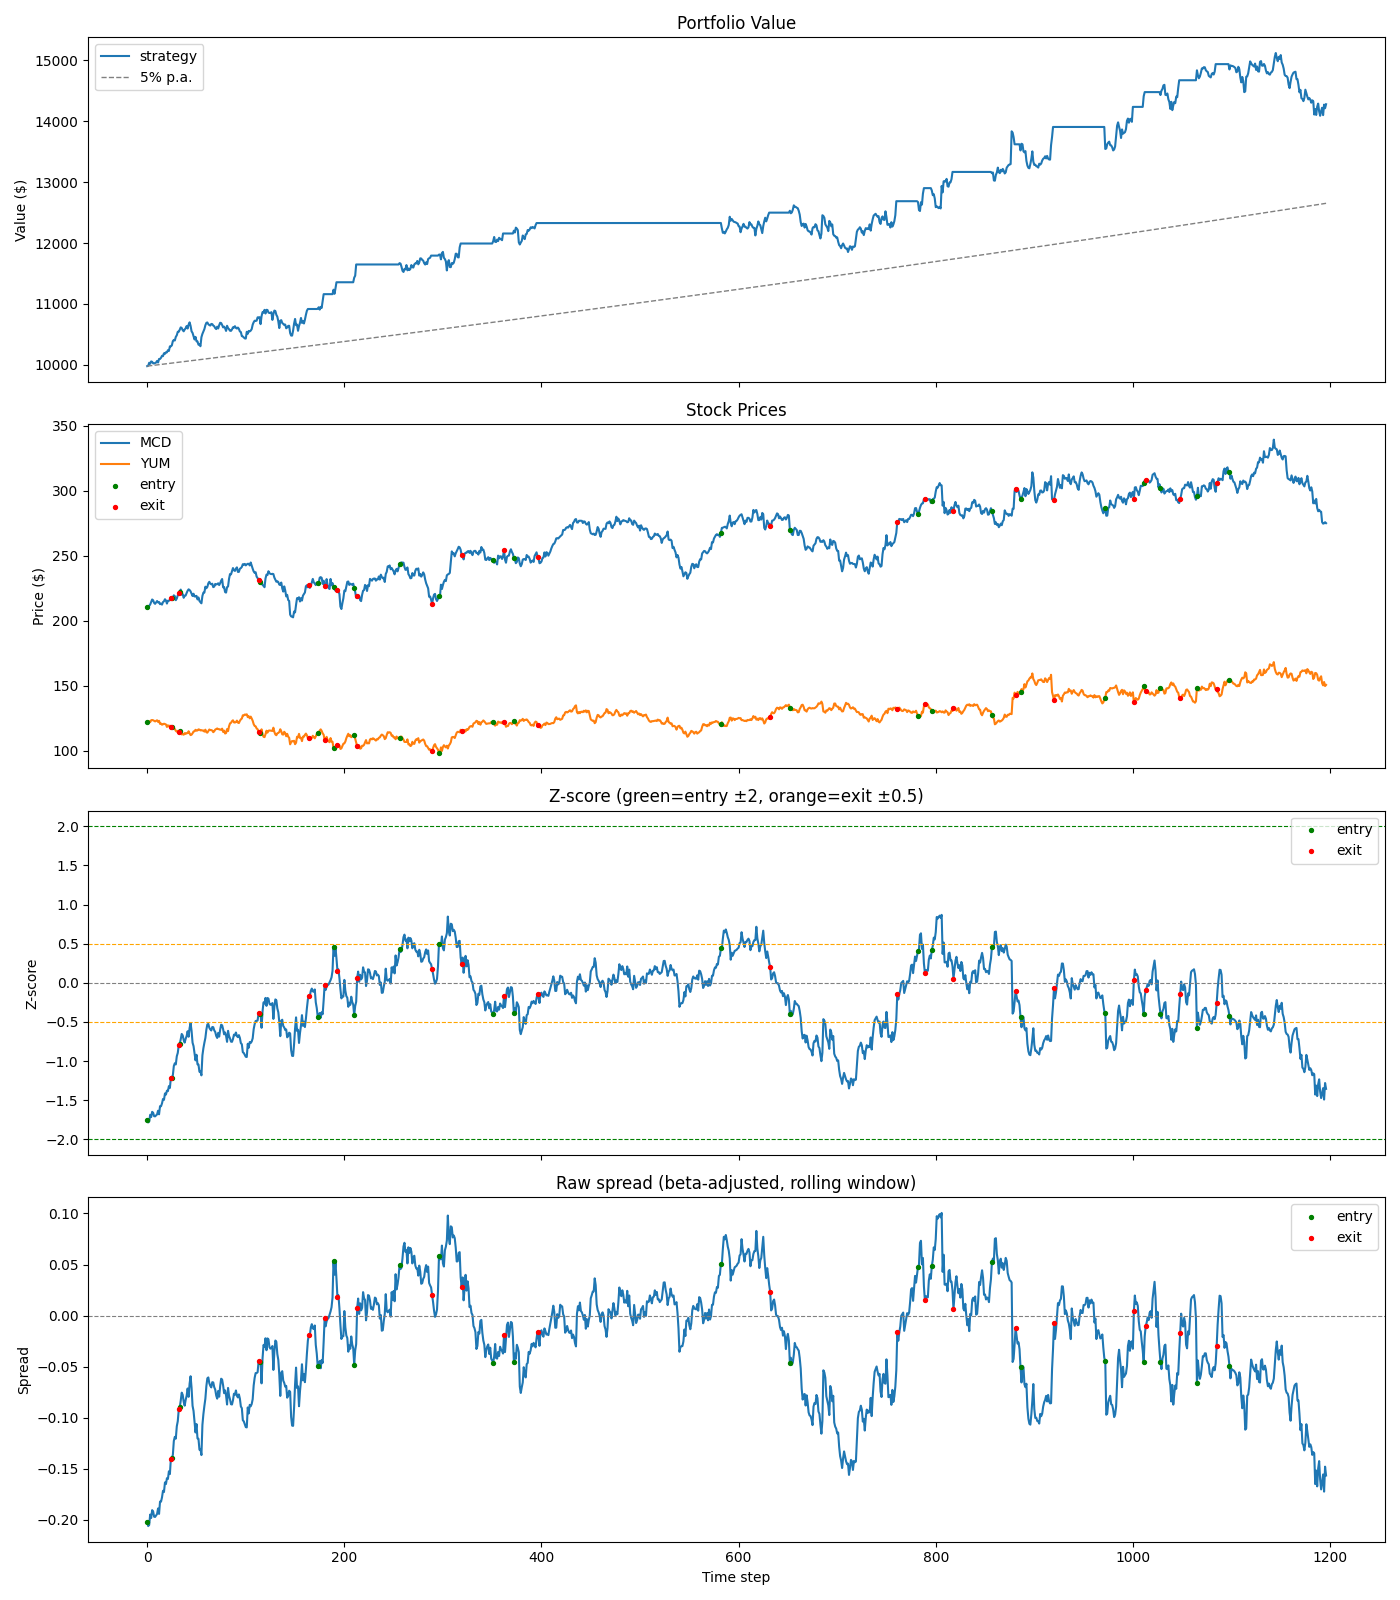

DQN v7 — real Q4
  Sharpe ratio      : 0.405
  Max drawdown      : -6.82%
  Annualised return : 7.83%

--- Z-score baseline (real Q4 test) ---


/home/tudor/TUDelft/Y3/RP/rl_for_pairs_trading/project/runner_books/../runner.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()
/home/tudor/TUDelft/Y3/RP/rl_for_pairs_trading/project/runner_books/../runner.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend()


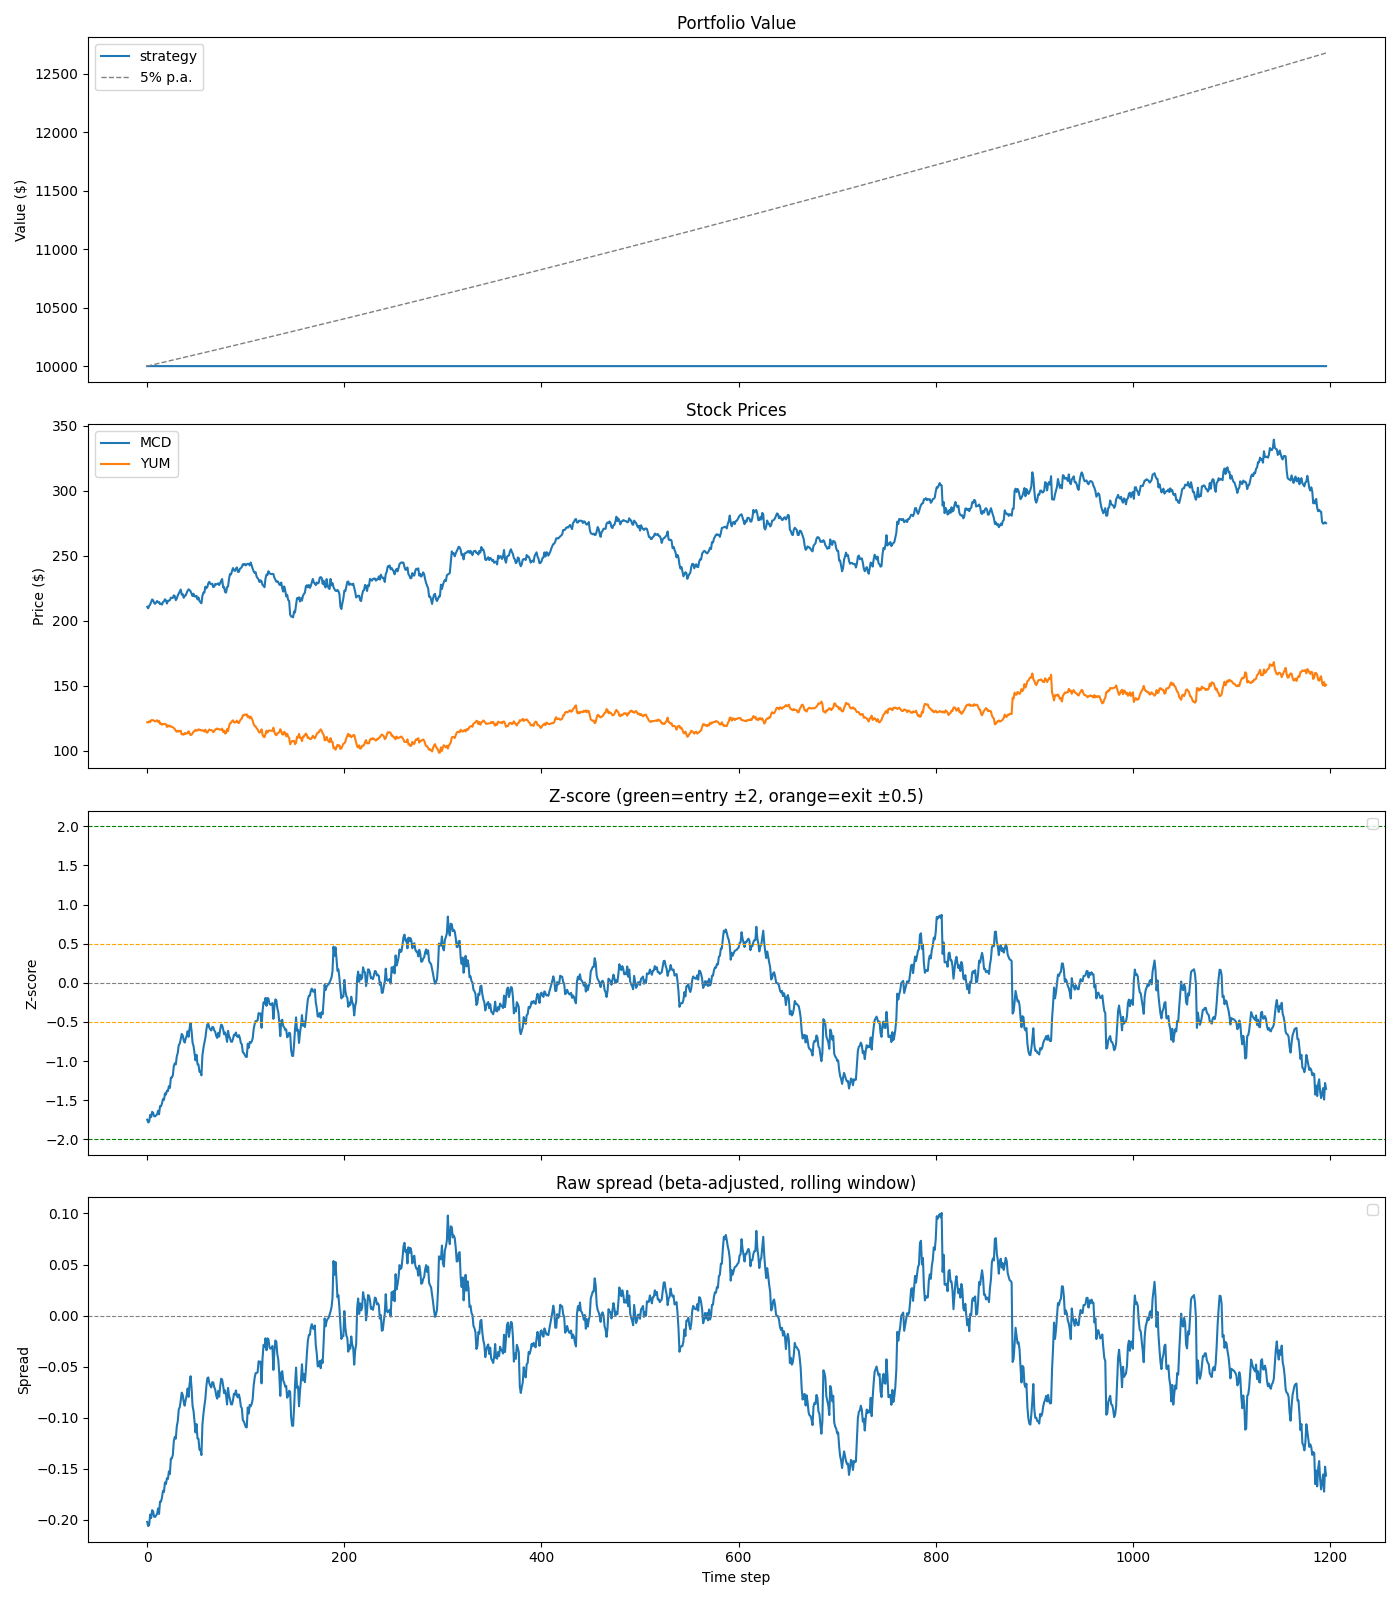

Z-score baseline — real Q4
  Sharpe ratio      : -3149703941.744
  Max drawdown      : 0.00%
  Annualised return : 0.00%



In [3]:
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

class SB3Agent:
    def __init__(self, model):
        self.model = model

    def predict(self, obs):
        flat = np.array([
            float(obs["position"]),
            abs(float(obs["spread_z_score"][0])),
            abs(float(obs["entry_z_score"][0])),
            abs(float(obs["spread"][0])),
            abs(float(obs["entry_spread"][0])),
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
            float(obs["rolling_mean"][0]),
            float(obs["rolling_std"][0]),
        ], dtype=np.float32)
        action, _ = self.model.predict(flat, deterministic=True)
        return int(action)

def metrics(results, label, rf_annual=0.05):
    pnl = results["pnl"]
    n_days         = len(pnl)
    daily_returns  = np.diff(pnl) / pnl[:-1]
    excess_returns = daily_returns - rf_annual / 252
    sharpe         = excess_returns.mean() / (excess_returns.std() + 1e-12) * np.sqrt(252)
    running_max    = np.maximum.accumulate(pnl)
    max_drawdown   = ((pnl - running_max) / running_max).min()
    total_return   = (pnl[-1] - pnl[0]) / pnl[0]
    ann_return     = (1 + total_return) ** (252 / n_days) - 1
    print(f"{label}")
    print(f"  Sharpe ratio      : {sharpe:.3f}")
    print(f"  Max drawdown      : {max_drawdown*100:.2f}%")
    print(f"  Annualised return : {ann_return*100:.2f}%")
    print()

env_kwargs = dict(fixed_beta=beta, spread_intercept=intercept, fixed_std=fixed_std)

q4_data = data.slice(q4)
results_dqn_q4 = run_strategy(Market(q4_data, **env_kwargs), SB3Agent(model))
print("--- DQN v7 mixed training (real Q4 test) ---")
plot_strategy(results_dqn_q4)
metrics(results_dqn_q4, "DQN v7 — real Q4")

results_base_q4 = run_strategy(Market(q4_data, **env_kwargs), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline (real Q4 test) ---")
plot_strategy(results_base_q4)
metrics(results_base_q4, "Z-score baseline — real Q4")

--- DQN v7 on synthetic series 0 ---


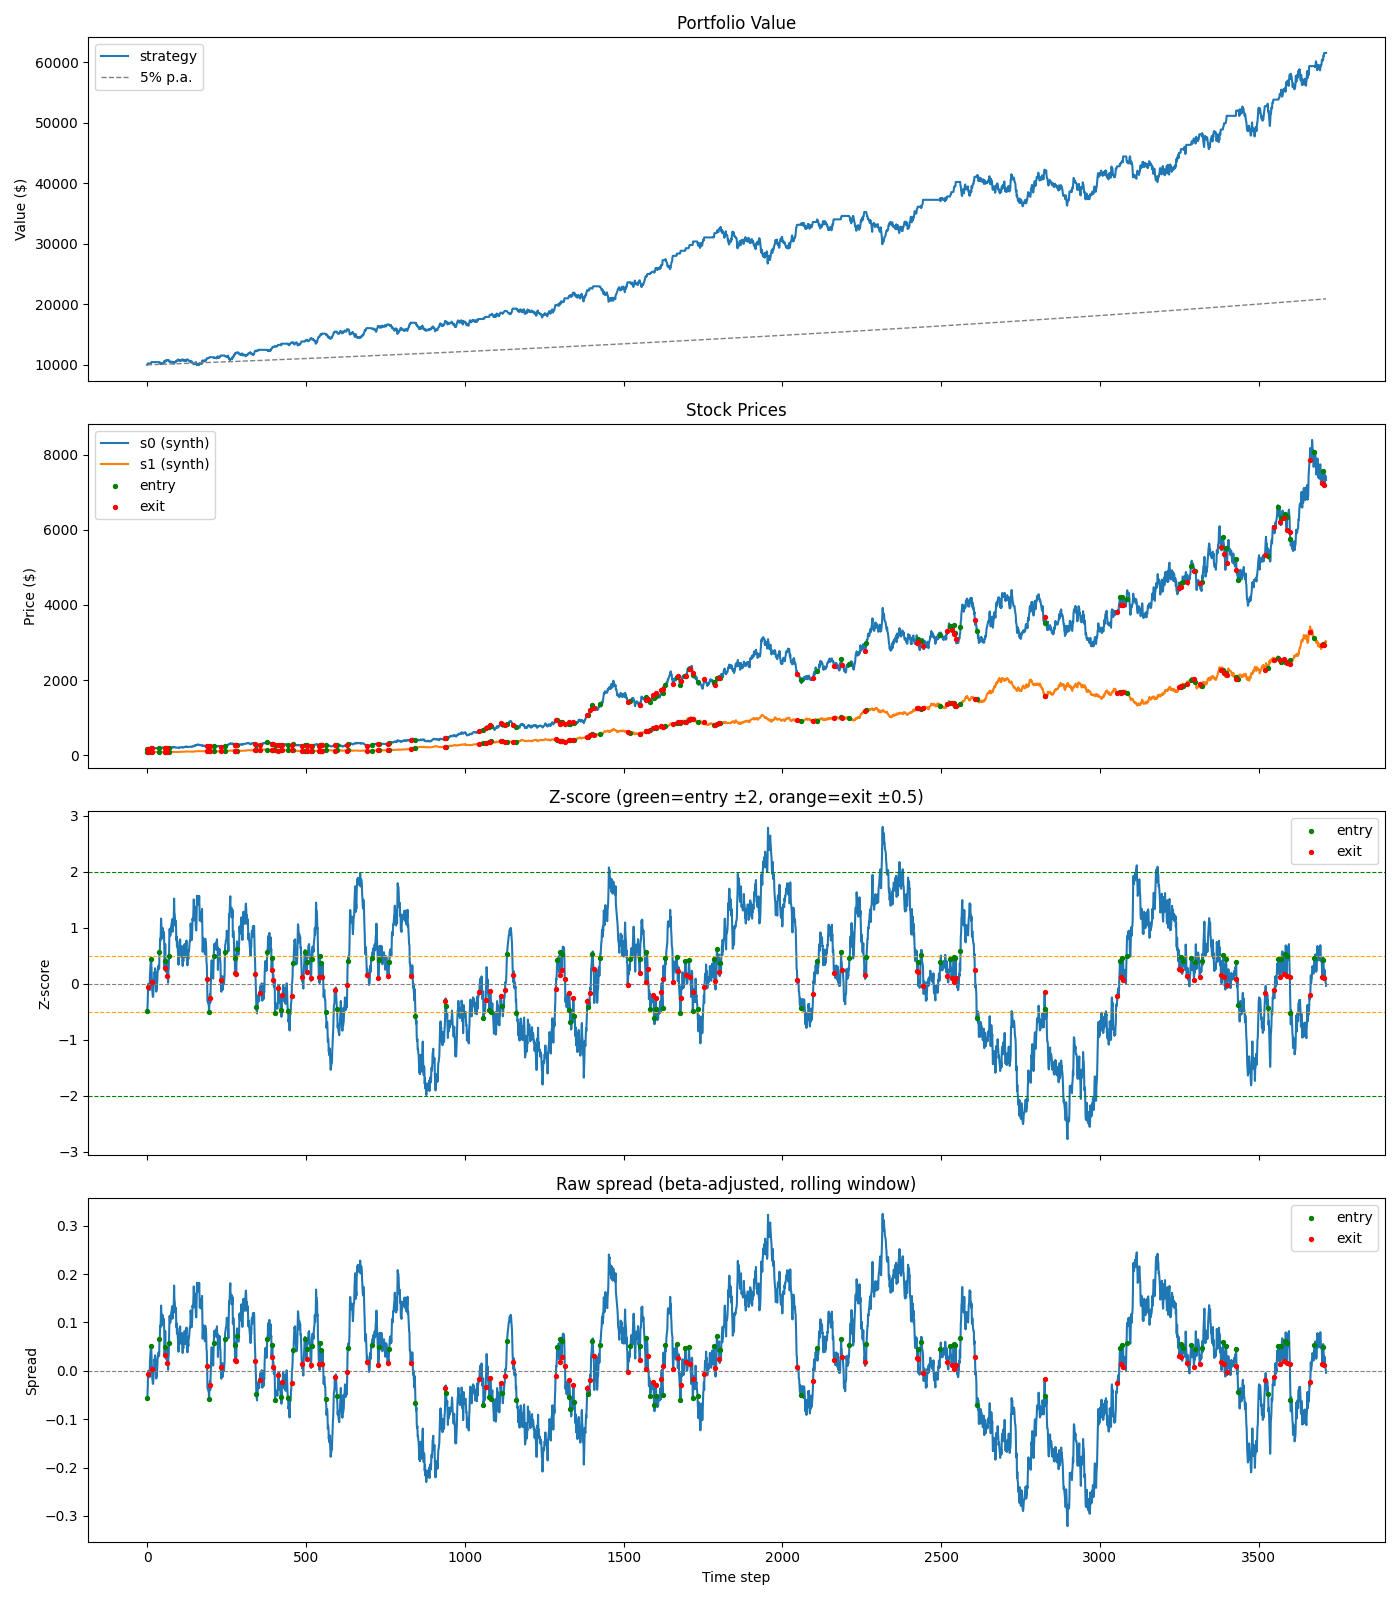

DQN v7 — synthetic series 0
  Sharpe ratio      : 0.623
  Max drawdown      : -18.48%
  Annualised return : 13.11%

--- Z-score baseline on synthetic series 0 ---


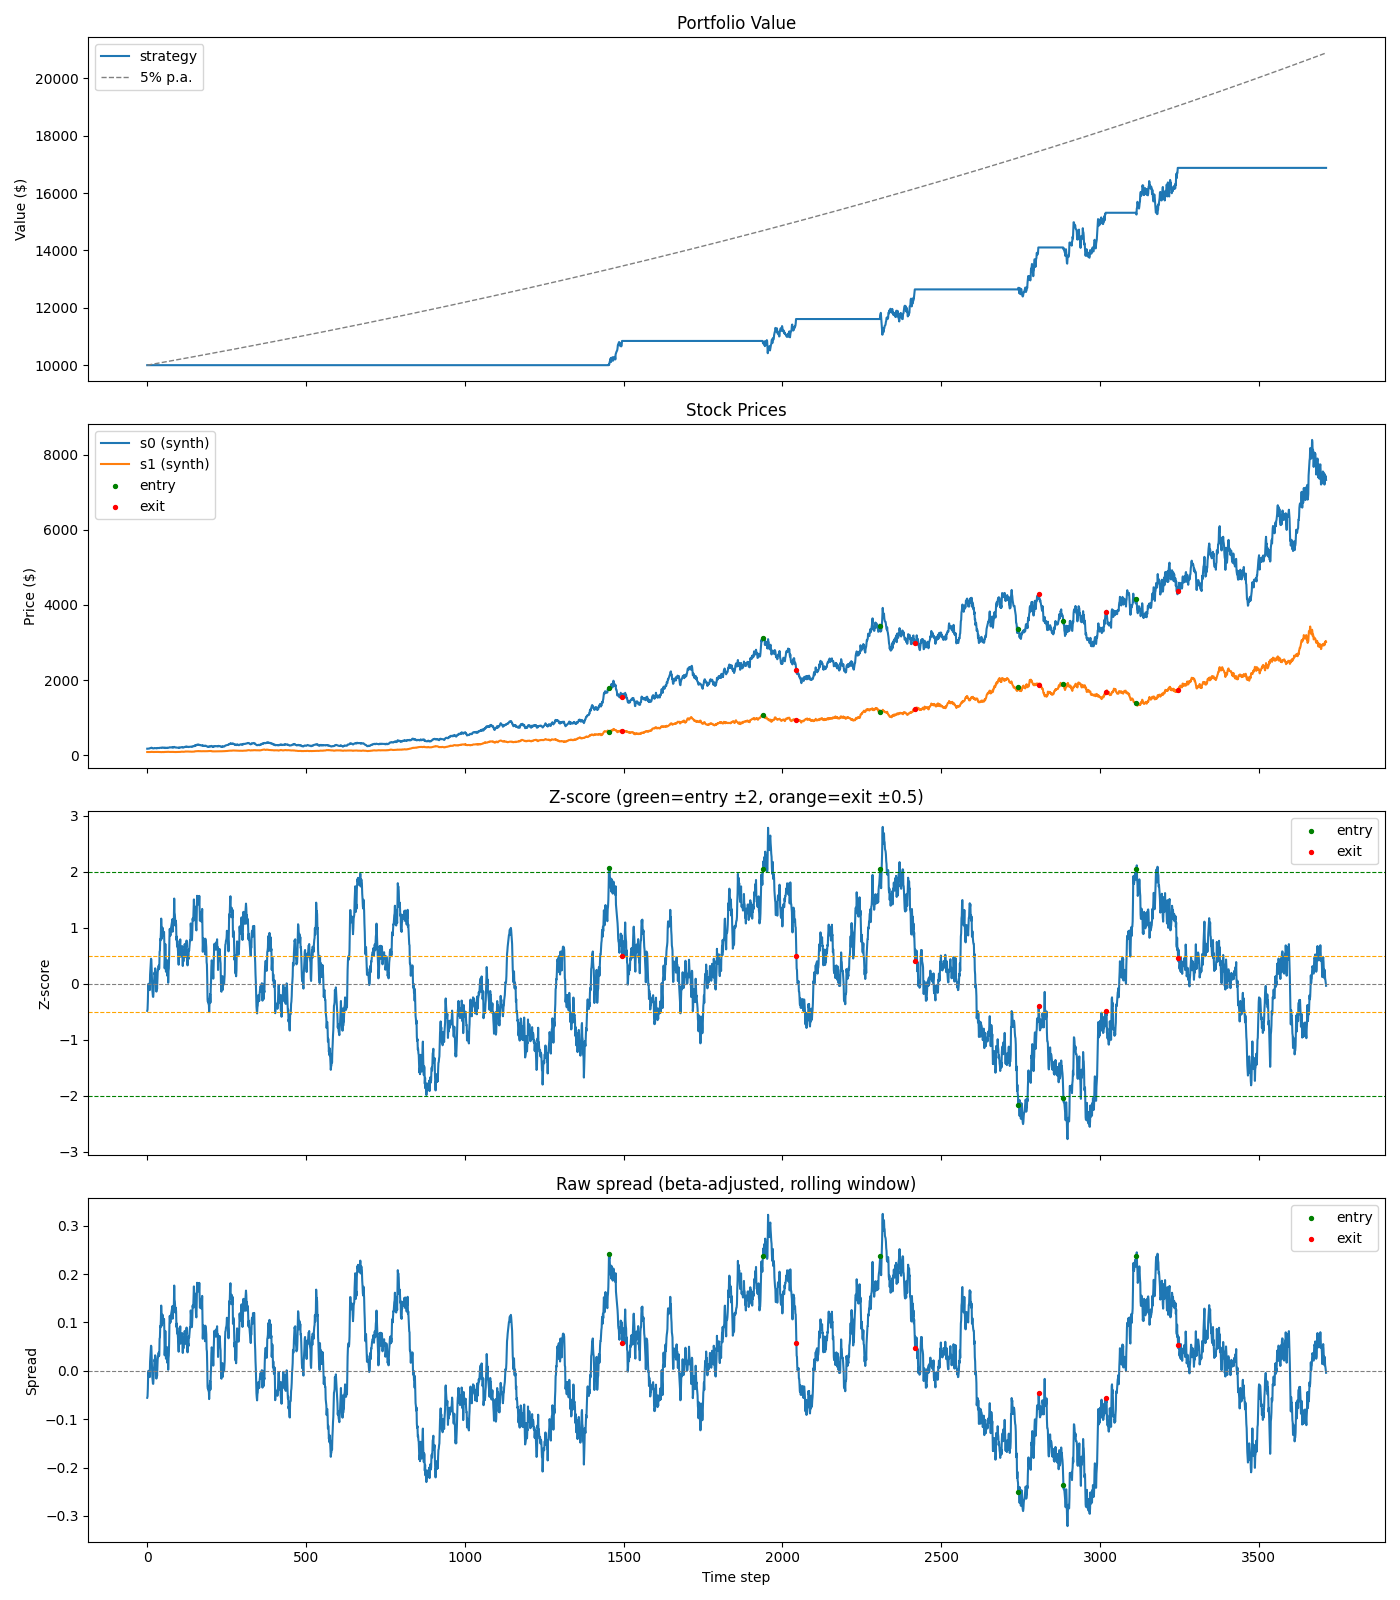

Z-score baseline — synthetic series 0
  Sharpe ratio      : -0.255
  Max drawdown      : -8.25%
  Annualised return : 3.62%



In [4]:
# DQN v7 on a single synthetic series (series 0)
synth_pair = object.__new__(PairData)
synth_pair.s = pairs[0]
synth_pair.labels = ["s0 (synth)", "s1 (synth)"]
synth_pair.timestamps = np.arange(pairs.shape[2])

results_dqn_synth = run_strategy(Market(synth_pair, **env_kwargs), SB3Agent(model))
print("--- DQN v7 on synthetic series 0 ---")
plot_strategy(results_dqn_synth)
metrics(results_dqn_synth, "DQN v7 — synthetic series 0")

results_base_synth = run_strategy(Market(synth_pair, **env_kwargs), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline on synthetic series 0 ---")
plot_strategy(results_base_synth)
metrics(results_base_synth, "Z-score baseline — synthetic series 0")

--- DQN v7 on unseen synthetic series ---


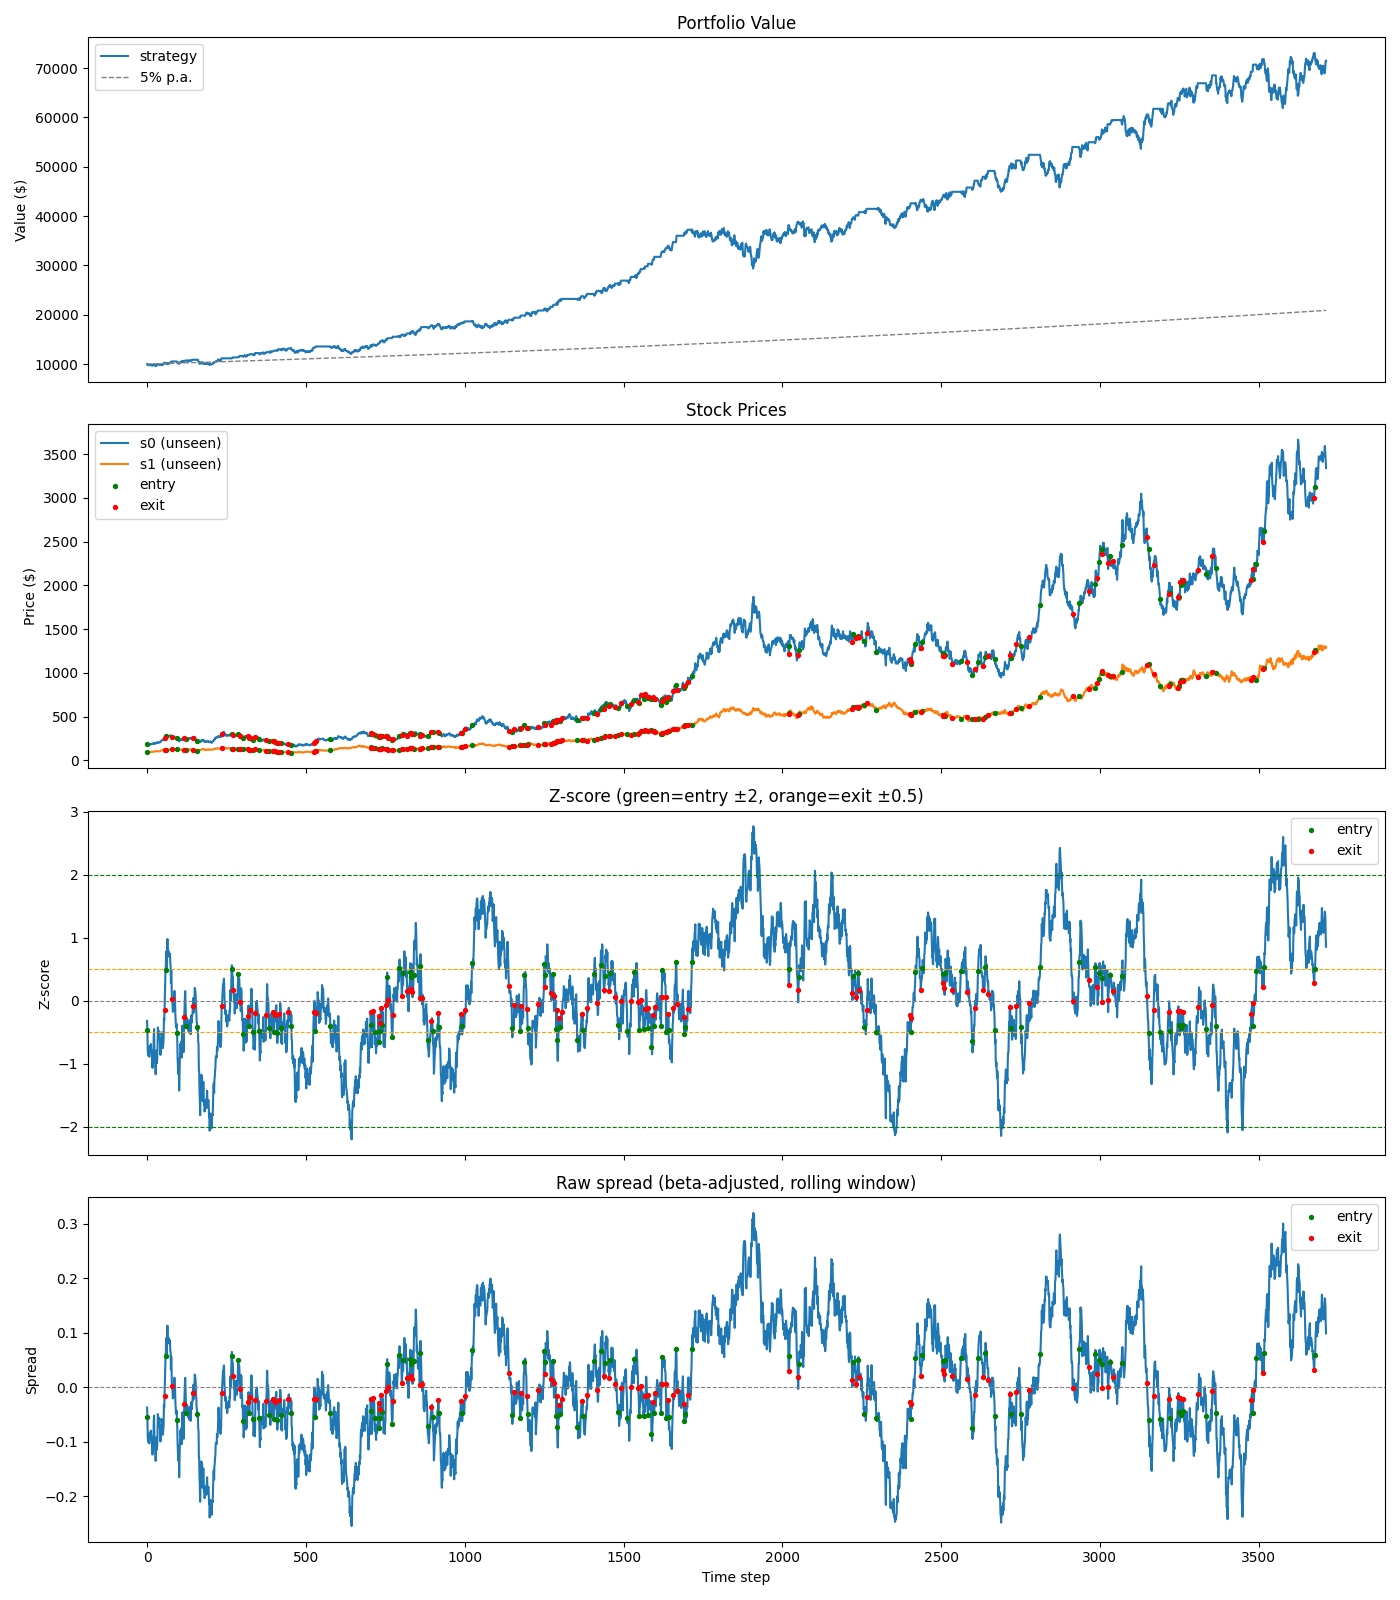

DQN v7 — unseen synthetic
  Sharpe ratio      : 0.717
  Max drawdown      : -21.81%
  Annualised return : 14.28%



In [5]:
# Unseen synthetic series (different seed, never seen during training)
rng_test = np.random.default_rng(999)
log_s1_unseen = np.cumsum(np.c_[np.full(1, np.log(100.0)),
                    0.0005 + 0.015 * rng_test.standard_normal((1, T - 1))], axis=1)
noise_unseen   = np.sqrt(wn_var) * rng_test.standard_normal((1, T))
spread_unseen  = np.zeros((1, T))
for t in range(1, T):
    spread_unseen[:, t] = phi * spread_unseen[:, t-1] + noise_unseen[:, t]
log_s0_unseen  = beta * log_s1_unseen + intercept + spread_unseen
pairs_unseen   = np.stack([np.exp(log_s0_unseen), np.exp(log_s1_unseen)], axis=1)

unseen_pair = object.__new__(PairData)
unseen_pair.s = pairs_unseen[0]
unseen_pair.labels = ["s0 (unseen)", "s1 (unseen)"]
unseen_pair.timestamps = np.arange(pairs_unseen.shape[2])

results_unseen = run_strategy(Market(unseen_pair, **env_kwargs), SB3Agent(model))
print("--- DQN v7 on unseen synthetic series ---")
plot_strategy(results_unseen)
metrics(results_unseen, "DQN v7 — unseen synthetic")